Vehicle safety is a critical concern for consumers, manufacturers, and regulators. The National Highway Traffic Safety Administration (NHTSA) conducts rigorous crash tests to evaluate how well vehicles protect occupants in collisions. These tests produce safety ratings (1-5 stars) that influence purchasing decisions and automotive design.


Key Motivations for This Project

-Consumer Safety Awareness
Many buyers rely on safety ratings when choosing a vehicle.
A predictive model can help consumers understand which safety features contribute most to high ratings.


-Automotive Industry Insights
Manufacturers can use this analysis to identify key safety improvements.
Understanding which crash test metrics most impact ratings can guide engineering decisions.


-Regulatory & Policy Implications
Governments and safety organizations can use ML models to assess trends in vehicle safety.
Helps identify gaps in safety standards and areas needing stricter regulations.


-Machine Learning Challenge
The dataset contains mixed data types (numerical, categorical, text) and missing values, making it a good case study for feature engineering and model selection.
Since safety ratings are ordinal (1-5 stars), this is a multiclass classification problem with real-world impact.


Business & Societal Impact

Consumers: Make better-informed decisions when purchasing vehicles.
Manufacturers: Optimize safety features to achieve higher ratings.
Regulators: Identify vehicles that may need stricter safety evaluations.


Why This Dataset?

Publicly available (NHTSA’s New Car Assessment Program).
Rich in features (128 variables including crash test results, safety systems, and vehicle specs).
Moderate size (~5,000+ rows filled with values of target variables otherwise 17000+ rows), suitable for ML modeling.
Not overused (unlike Titanic, Iris, or MNIST datasets).


Classification Goal

Predict OVERALL_STARS (1-5 stars) based on the information provided in the dataset

This project will help bridge the gap between raw crash test data and actionable safety insights—benefitting consumers, automakers, and policymakers alike.




In [2]:
import pandas as pd

# Loading the dataset Raw_Data
df = pd.read_csv("raw_data.csv", low_memory=False)

# Basic info of the dataset with dtype and name of the columns 
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11757 entries, 0 to 11756
Data columns (total 128 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    MAKE                          object 
 1    MODEL                         object 
 2    MODEL_YR                      int64  
 3    BODY_STYLE                    object 
 4    VEHICLE_TYPE                  object 
 5    DRIVE_TRAIN                   object 
 6    PRODUCTION_RELEASE            int64  
 7    VEHICLE_CLASS                 object 
 8    BODY_FRAME                    object 
 9    NUM_OF_SEATING                object 
 10   SEAT_LOC                      object 
 11   SEAT_LOC_COMMENTS             object 
 12   MIN_GROSS_WEIGHT              float64
 13   MAX_GROSS_WEIGHT              float64
 14   UPPER_BELT_ANCHORAGE          object 
 15   UPPER_BELT_ANCHORAGE_LOC      object 
 16   SEAT_BELT_PRETENSIONER        object 
 17   SEAT_BELT_PRETENSIONER_LOC    object 
 18   LOAD

In [3]:
# Display first few rows to get an idea of the data

df.head()

,MAKE,MODEL,MODEL_YR,BODY_STYLE,VEHICLE_TYPE,DRIVE_TRAIN,PRODUCTION_RELEASE,VEHICLE_CLASS,BODY_FRAME,NUM_OF_SEATING,...,POLE_HIC_36_DRIV,PELVIC_FORCE,ROLLOVER_POSSIBILITY,STATIC_STABI_FACTOR,TIP,ROLL_SAFETY_CONCERN,ROLL_FOOT_NOTES,ROLLOVER_STARS,NHTSA_BACKUP_CAMERA,BACKUP_CAMERA
0,ACURA,ADX,2025,SUV,MPV,AWD,1,NaN,,5,...,NaN,NaN,0.000,0.00,NaN,NaN,NaN,NaN,NaN,NaN
1,ACURA,ADX,2025,SUV,MPV,FWD,1,NaN,,5,...,NaN,NaN,0.000,0.00,NaN,NaN,NaN,NaN,NaN,NaN
2,ACURA,INTEGRA,2025,5 HB,PC,FWD,1,NaN,,5,...,235.989,2871.970,0.095,1.48,No Tip,NaN,NaN,5.0,NaN,NaN
3,ACURA,INTEGRA TYPE-S,2025,5 HB,PC,FWD,1,NaN,,4,...,NaN,NaN,0.095,1.48,No Tip,NaN,NaN,5.0,NaN,NaN
4,ACURA,MDX,2025,SUV,MPV,AWD,1,NaN,,7,...,549.430,1886.689,0.151,NaN,No Tip,NaN,NaN,NaN,NaN,NaN


In [4]:
# some more information about the dataset : count by dtypes and finding the null values

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic info
print(f"Dataset shape - Rows, Columns : {df.shape}")
print("\nCount by Data types:")
print(df.dtypes.value_counts())

# Missing values analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing/len(df))*100
print("\nMissing values by percentage:")
print(missing_percent[missing_percent > 50])

Dataset shape - Rows, Columns : (11757, 128)

Count by Data types:
object     84
float64    42
int64       2
Name: count, dtype: int64

Missing values by percentage:
FRNT_SAFETY_CONCERN_DRIV    99.957472
FRNT_SAFETY_CONCERN_PASS    99.948967
POLE_SAFETY_CONCERN         99.829889
FRNT_FOOT_NOTES_PASS        99.821383
SIDE_SAFETY_CONCERN_DRIV    99.821383
                              ...    
FRNT_PASS_STARS             53.593604
POLE_VIN                    53.593604
FRNT_DRIV_STARS             53.568087
POLE_TEST_NO                53.346942
SIDE_POLE_STARS             53.287403
Length: 70, dtype: float64


In [5]:
# We will be working on a classification problem where the dataset will be used to predict the target variable 'OVERALL_STARS'. 
# Finding the null values for the target column

print(df['OVERALL_STARS'].isnull().sum())

6629


In [6]:
print(df['OVERALL_STARS'].value_counts())

OVERALL_STARS
5.0    3213
4.0    1773
3.0     116
2.0      26
Name: count, dtype: int64


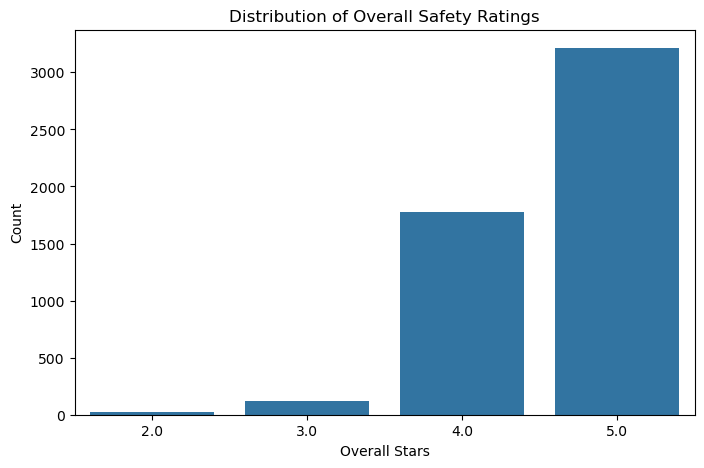

In [7]:
# Target variable distribution (looks unbalanced)

plt.figure(figsize=(8,5))
sns.countplot(x='OVERALL_STARS', data=df)
plt.title('Distribution of Overall Safety Ratings')
plt.xlabel('Overall Stars')
plt.ylabel('Count')
plt.show()


In [8]:
# droping the rows where Target values are null

df.dropna(subset=['OVERALL_STARS'], inplace=True)

In [9]:
# re-printing the shape of the dataframe

df.shape

(5128, 128)

In [10]:
# Checking other columns where null values are more than 50%

nulls_df = df.isnull().sum().sort_values(ascending=False).reset_index()

nulls_df.columns = ['Column', 'Null Count']

nulls_df_temp = nulls_df[nulls_df['Null Count'] > len(df) *.50]

print(list(nulls_df_temp['Column']))

print("\n",list(nulls_df_temp['Null Count']))

['FRNT_SAFETY_CONCERN_DRIV', 'FRNT_SAFETY_CONCERN_PASS', 'FRNT_FOOT_NOTES_PASS', 'SIDE_SAFETY_CONCERN_DRIV', 'POLE_SAFETY_CONCERN', 'ADAPTIVE_CRUISE_CONTROL', 'ROLL_FOOT_NOTES', 'ABS', 'SIDE_SAFETY_CONCERN_PASS', 'ADL', 'BETI', 'ROLL_SAFETY_CONCERN', 'FRNT_FOOT_NOTES', 'SIDE_FOOT_NOTES_PASS', 'POLE_FOOT_NOTES', 'NHTSA_BACKUP_CAMERA', 'SIDE_FOOT_NOTES', 'REAR_BELT_INDICATOR', 'NHTSA_LDW_EVALUATION', 'NHTSA_DBS_EVALUATION', 'NHTSA_CIB_EVALUATION', 'NHTSA_FCW_EVALUATION', 'DYNAMIC_HEAD_RESTRAINT_IND', 'NHTSA_ESC', 'BACKUP_CAMERA', 'SEAT_LOC_COMMENTS', 'PELVIS_SAB_TYPE', 'PELVIS_SAB_LOC']

 [5123, 5122, 5112, 5109, 5108, 5094, 5067, 5062, 5031, 4964, 4952, 4944, 4902, 4746, 4731, 4672, 4611, 4453, 4130, 4124, 4124, 4119, 3992, 3976, 3751, 3444, 2856, 2825]


In [11]:
# Columns to drop
drop_cols = [
    # High missing values
    'FRNT_SAFETY_CONCERN_DRIV', 'FRNT_SAFETY_CONCERN_PASS', 'FRNT_FOOT_NOTES_PASS', 'SIDE_SAFETY_CONCERN_DRIV',
    'POLE_SAFETY_CONCERN', 'ADAPTIVE_CRUISE_CONTROL', 'ROLL_FOOT_NOTES', 'ABS', 'SIDE_SAFETY_CONCERN_PASS', 'ADL',
    'BETI', 'ROLL_SAFETY_CONCERN', 'FRNT_FOOT_NOTES', 'SIDE_FOOT_NOTES_PASS', 'POLE_FOOT_NOTES', 'NHTSA_BACKUP_CAMERA', 
    'SIDE_FOOT_NOTES', 'REAR_BELT_INDICATOR', 'NHTSA_LDW_EVALUATION', 'NHTSA_DBS_EVALUATION', 'NHTSA_CIB_EVALUATION', 
    'NHTSA_FCW_EVALUATION', 'DYNAMIC_HEAD_RESTRAINT_IND', 'NHTSA_ESC', 'BACKUP_CAMERA', 'SEAT_LOC_COMMENTS', 
    'PELVIS_SAB_TYPE', 'PELVIS_SAB_LOC',

    
    # Identifiers which are irrelevant 
    'FRNT_VIN', 'SIDE_VIN', 'POLE_VIN',
    'FRNT_TEST_NO', 'SIDE_TEST_NO', 'POLE_TEST_NO','PRODUCTION_RELEASE',

    
    # Redundant safety rating columns
    
    'FRNT_DRIV_STARS', 'FRNT_PASS_STARS', 'OVERALL_FRNT_STARS',
    'SIDE_DRIV_STARS', 'SIDE_PASS_STARS', 'SIDE_BARRIER_STAR',
    'COMB_FRNT_STAR', 'COMB_REAR_STAR', 'OVERALL_SIDE_STARS',
    'SIDE_POLE_STARS', 'ROLLOVER_STARS'

]

# Droping the above columns
df_clean = df.drop(columns=drop_cols)

In [12]:
# Defining the numerical and categorical variables

numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_cols,'\n')
print("Categorical features:", categorical_cols)


Numerical features: ['MODEL_YR', 'MIN_GROSS_WEIGHT', 'MAX_GROSS_WEIGHT', 'OVERALL_STARS', 'CURB_WEIGHT', 'HIC15_DRIV', 'CHEST_DEFL_DRIV', 'LEFT_FEMUR_DRIV', 'RIGHT_FEMUR_DRIV', 'NIJ_DRIV', 'NECK_TENS_DRIV', 'NET_COMP_DRIV', 'HIC15_PASS', 'CHEST_DEFL_PASS', 'LEFT_FEMUR_PASS', 'RIGHT_FEMUR_PASS', 'NIJ_PASS', 'NECK_TENS_PASS', 'NET_COMP_PASS', 'SIDE_HIC_36_DRIV', 'RIB_DEFLECTION_DRIV', 'ABDOMEN_FORCE_DRIV', 'SYMPHYSIS_FORCE_DRIV', 'SIDE_HIC_36_PASS', 'PELVIC_FORCE_PASS', 'POLE_HIC_36_DRIV', 'PELVIC_FORCE', 'ROLLOVER_POSSIBILITY', 'STATIC_STABI_FACTOR'] 

Categorical features: ['MAKE', 'MODEL', 'BODY_STYLE', 'VEHICLE_TYPE', 'DRIVE_TRAIN', 'VEHICLE_CLASS', 'BODY_FRAME', 'NUM_OF_SEATING', 'SEAT_LOC', 'UPPER_BELT_ANCHORAGE', 'UPPER_BELT_ANCHORAGE_LOC', 'SEAT_BELT_PRETENSIONER', 'SEAT_BELT_PRETENSIONER_LOC', 'LOAD_LIMITERS', 'LOAD_LIMITERS_LOC', 'FRNT_BELT_INDICATOR', 'FRNT_BELT_LOC', 'LATCH_REAR_POSITION', 'HEAD_SAB', 'HEAD_SAB_TYPE', 'HEAD_SAB_LOC', 'HEAD_SAB_MOUNT_LOC', 'HEAD_SAB_MEET_REQUI

In [13]:
# Numerical variables decription

df_clean[numerical_cols].describe()


,MODEL_YR,MIN_GROSS_WEIGHT,MAX_GROSS_WEIGHT,OVERALL_STARS,CURB_WEIGHT,HIC15_DRIV,CHEST_DEFL_DRIV,LEFT_FEMUR_DRIV,RIGHT_FEMUR_DRIV,NIJ_DRIV,...,SIDE_HIC_36_DRIV,RIB_DEFLECTION_DRIV,ABDOMEN_FORCE_DRIV,SYMPHYSIS_FORCE_DRIV,SIDE_HIC_36_PASS,PELVIC_FORCE_PASS,POLE_HIC_36_DRIV,PELVIC_FORCE,ROLLOVER_POSSIBILITY,STATIC_STABI_FACTOR
count,5128.000000,4722.000000,4726.000000,5128.000000,5090.000000,4638.000000,4638.000000,4638.000000,4638.000000,4638.000000,...,4634.000000,4634.000000,4634.000000,4634.000000,4499.000000,4499.000000,4634.000000,4634.000000,5128.000000,5111.000000
mean,2018.335218,5421.688098,5715.562040,4.593799,4063.561690,215.606786,23.466312,1542.346569,1810.105135,0.294892,...,98.247847,21.640574,723.619785,1406.104085,193.973539,2555.810847,351.457948,3213.319904,0.153087,1.296787
std,4.099236,1346.445583,1484.370843,0.562962,1175.611467,88.433618,4.776524,1046.602656,994.751524,0.072281,...,64.512826,7.044225,283.008382,520.974040,132.826546,1055.438023,712.224111,800.570261,0.059683,0.135720
min,2011.000000,7.000000,505.000000,2.000000,0.000000,67.312000,9.493000,48.207000,56.017000,0.160000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,4475.000000,4680.000000,4.000000,3414.000000,151.557000,20.210000,727.703000,1160.696000,0.242500,...,51.997000,16.609000,504.102000,1035.229000,92.723000,1788.800000,237.749000,2639.706000,0.107000,1.200000
50%,2018.000000,5100.000000,5401.000000,5.000000,3982.000000,200.127000,22.994000,1414.992000,1719.957000,0.290000,...,82.777000,21.482000,692.371000,1366.163000,162.245000,2542.742000,293.138500,3144.957000,0.155000,1.260000
75%,2022.000000,6168.000000,6459.000000,5.000000,4671.250000,257.128000,26.298000,2137.459000,2347.276000,0.330000,...,134.545000,26.131000,872.914250,1688.813000,271.656000,3286.273000,364.533000,3699.114000,0.185000,1.410000
max,2025.000000,9900.000000,11000.000000,5.000000,7586.000000,821.865000,46.786000,5927.830000,6801.413000,0.610000,...,387.926000,52.008000,2234.137000,3969.616000,819.636000,6357.052000,12246.016000,7430.367000,1.330000,1.920000


In [14]:
# # Categorical variables description 
# for col in categorical_cols[:5]:  # Only first 5 for brevity
#     print(df_clean[col].value_counts().head(5))


OVERALL_STARS           1.000000
STATIC_STABI_FACTOR     0.445106
MODEL_YR                0.289331
SIDE_HIC_36_DRIV        0.197973
SIDE_HIC_36_PASS        0.047858
ABDOMEN_FORCE_DRIV      0.036251
PELVIC_FORCE_PASS      -0.022819
SYMPHYSIS_FORCE_DRIV   -0.104878
RIB_DEFLECTION_DRIV    -0.125360
HIC15_PASS             -0.194058
CURB_WEIGHT            -0.210369
NET_COMP_PASS          -0.234899
POLE_HIC_36_DRIV       -0.241743
RIGHT_FEMUR_PASS       -0.292605
NIJ_DRIV               -0.296006
HIC15_DRIV             -0.301292
NET_COMP_DRIV          -0.303650
CHEST_DEFL_PASS        -0.310673
RIGHT_FEMUR_DRIV       -0.314415
MIN_GROSS_WEIGHT       -0.320492
MAX_GROSS_WEIGHT       -0.337111
LEFT_FEMUR_PASS        -0.338135
NECK_TENS_DRIV         -0.342446
CHEST_DEFL_DRIV        -0.349804
PELVIC_FORCE           -0.386421
LEFT_FEMUR_DRIV        -0.434198
NECK_TENS_PASS         -0.450493
ROLLOVER_POSSIBILITY   -0.454247
NIJ_PASS               -0.513281
Name: OVERALL_STARS, dtype: float64


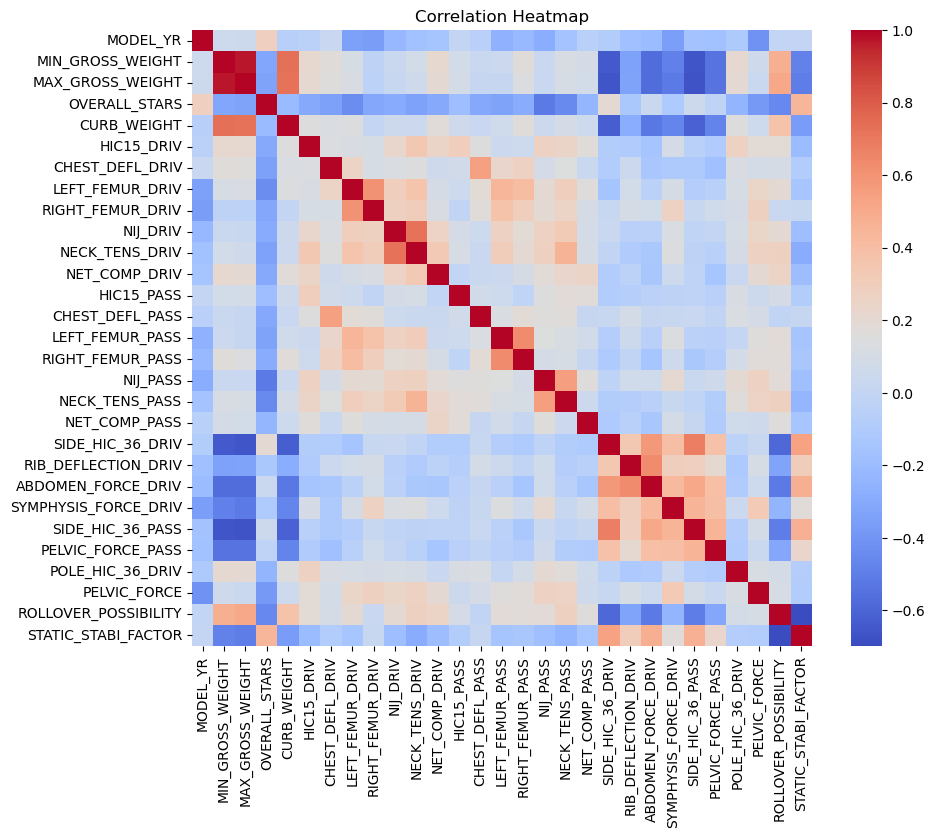

In [15]:
# correlation matrix 

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df_clean[numerical_cols].corr()

# Get correlation of each feature with OVERALL_STARS
top_corr = corr_matrix['OVERALL_STARS'].sort_values(ascending=False)
print(top_corr)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()


In [16]:
# Removing Highly correalted feilds MAX_GROSS_WEIGHT
df_clean = df.drop(columns=drop_cols)

numerical_cols.remove('MAX_GROSS_WEIGHT')

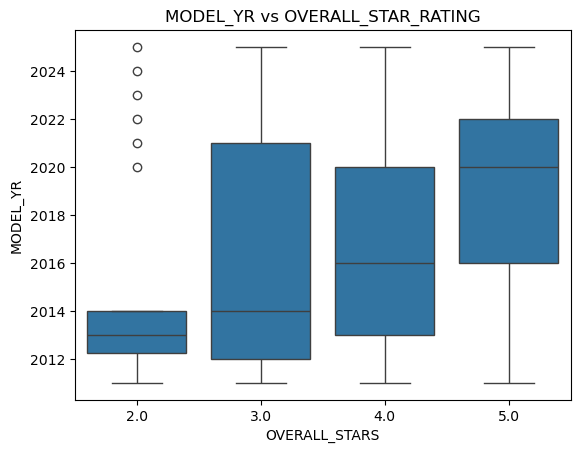

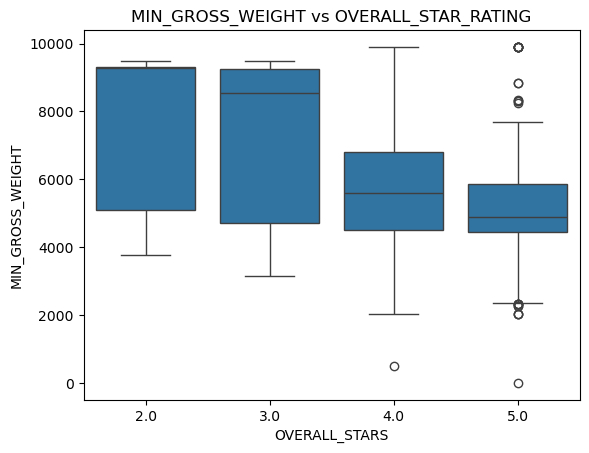

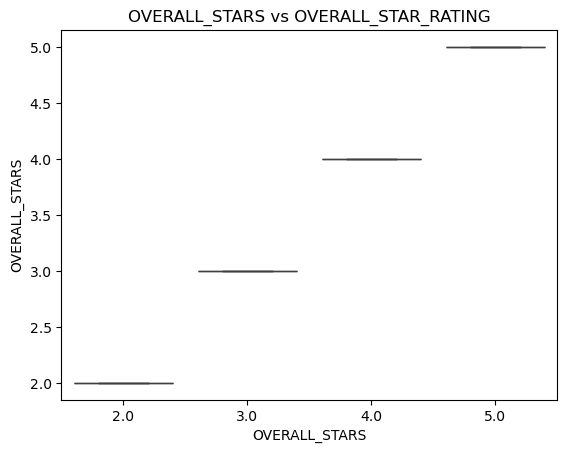

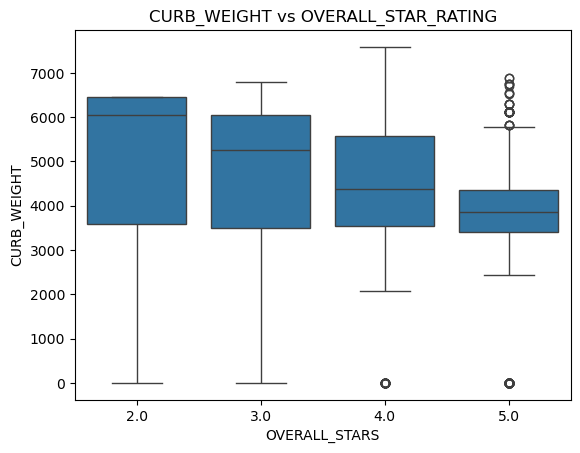

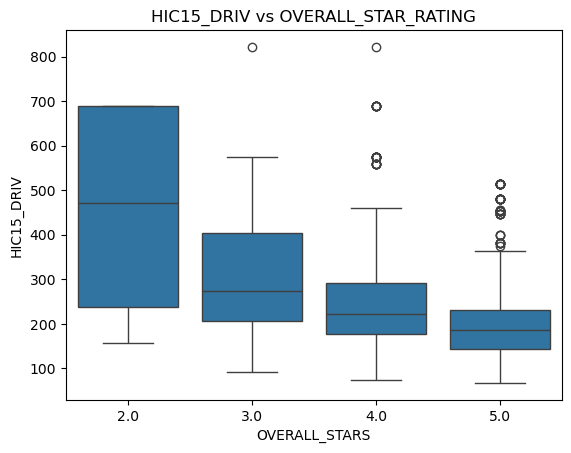

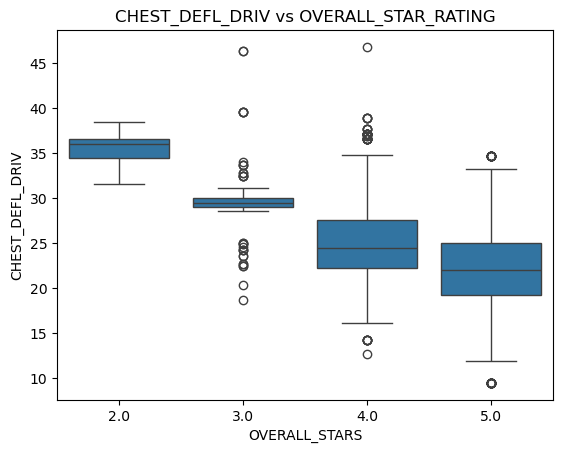

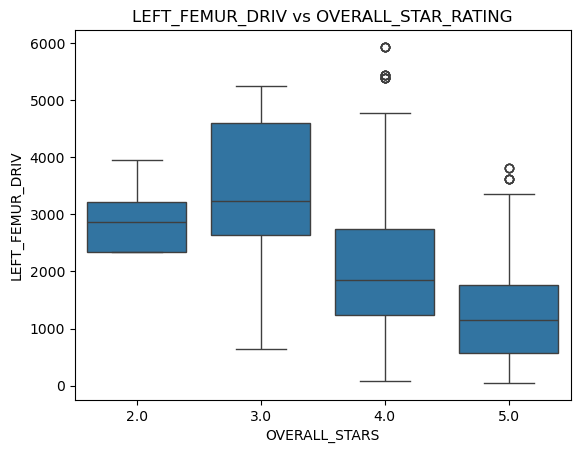

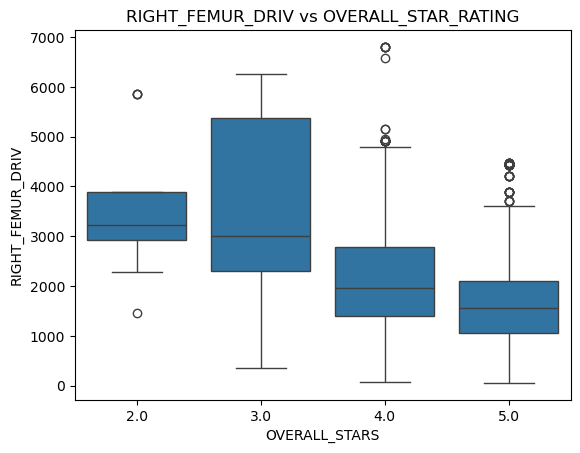

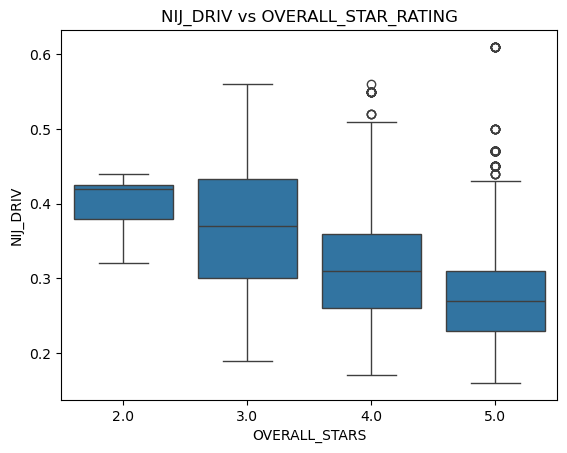

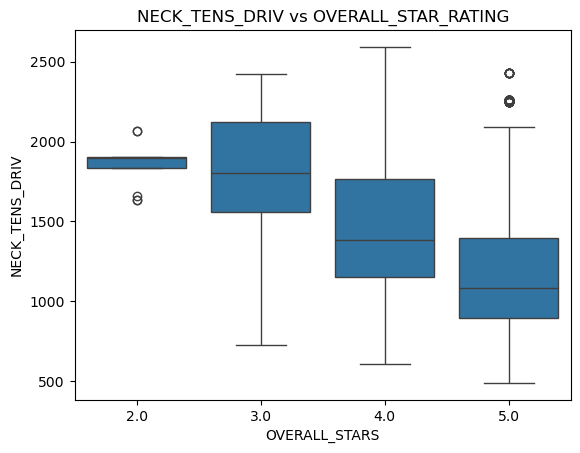

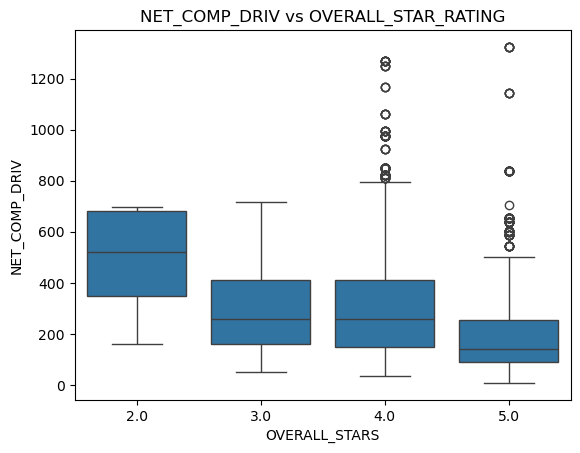

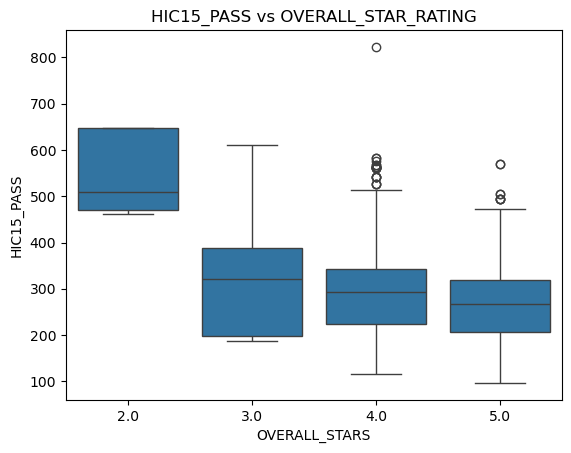

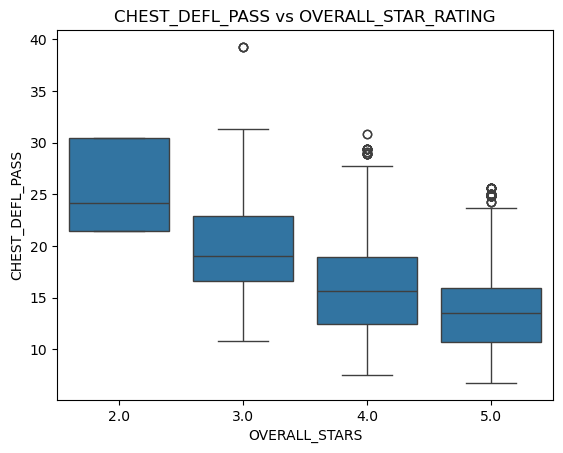

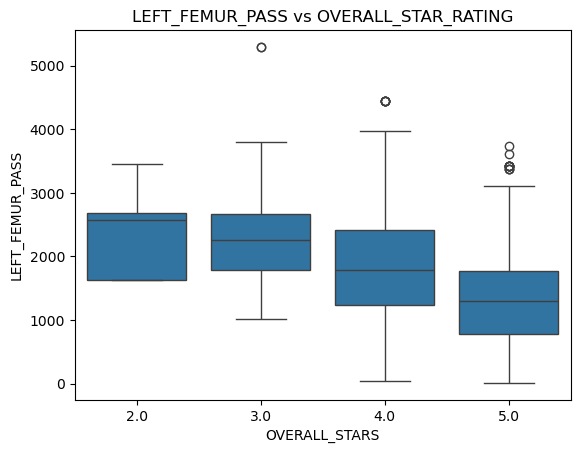

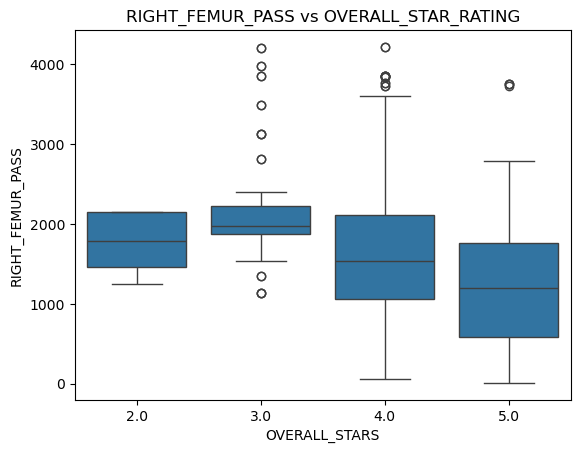

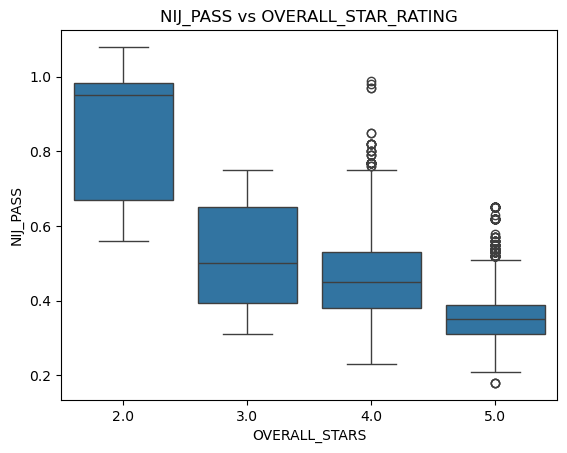

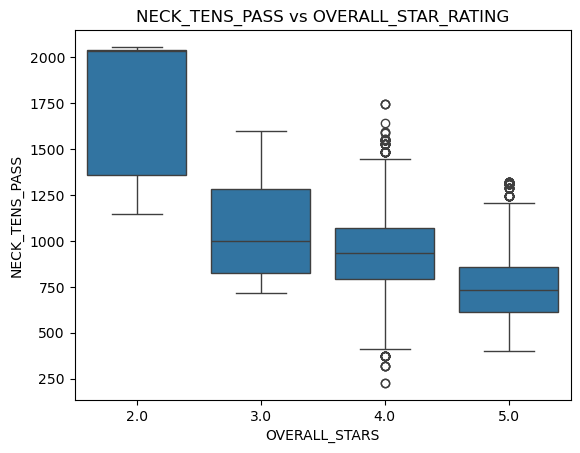

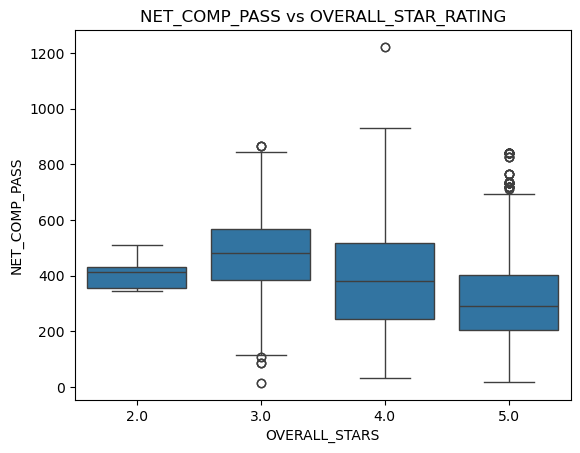

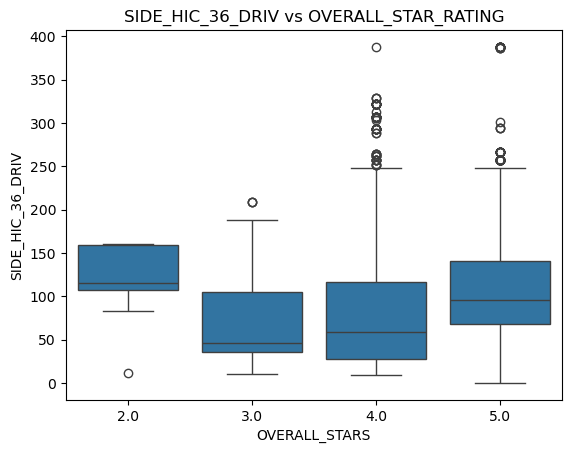

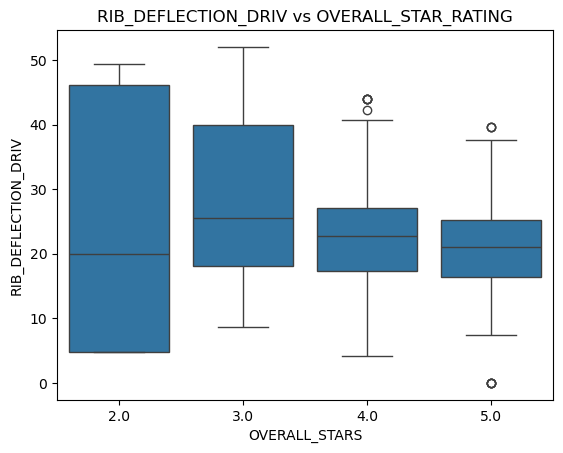

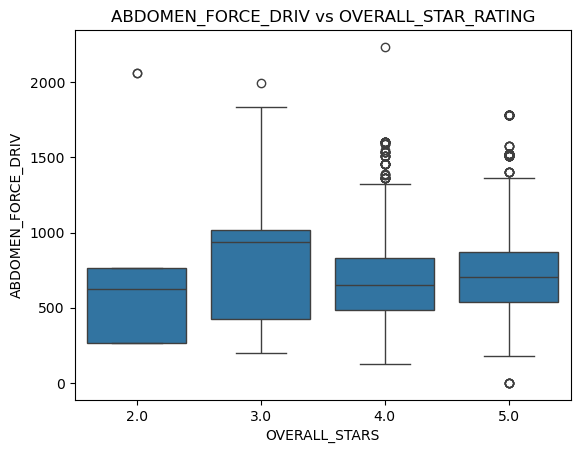

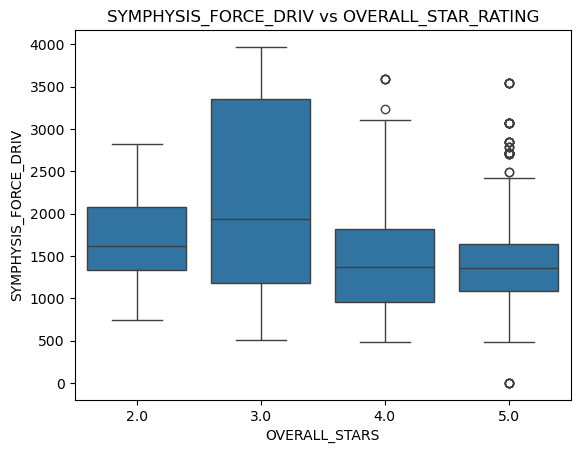

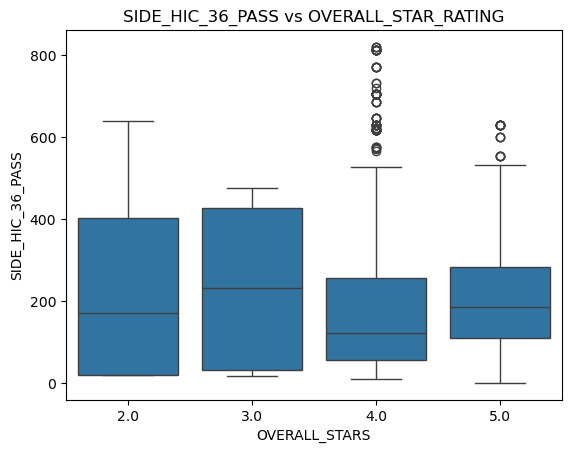

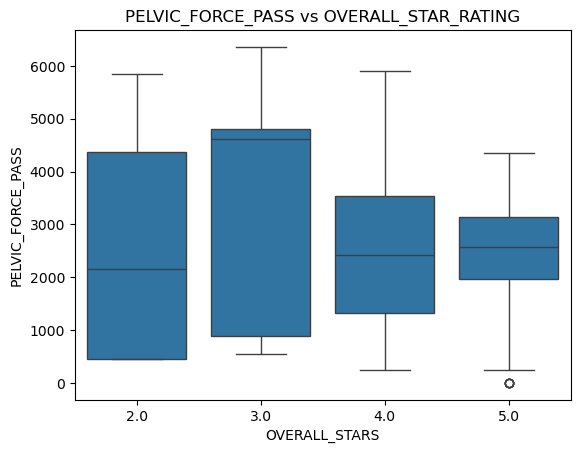

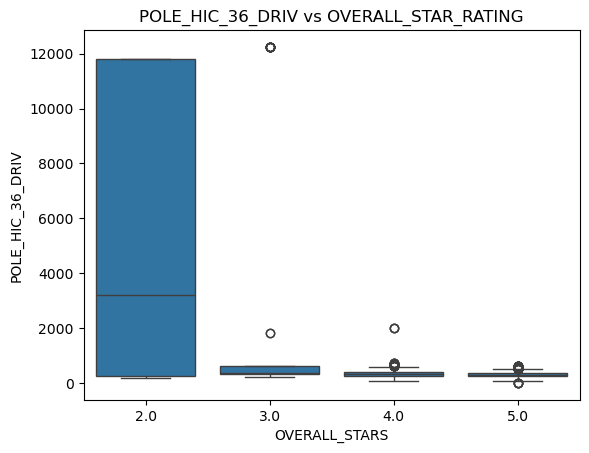

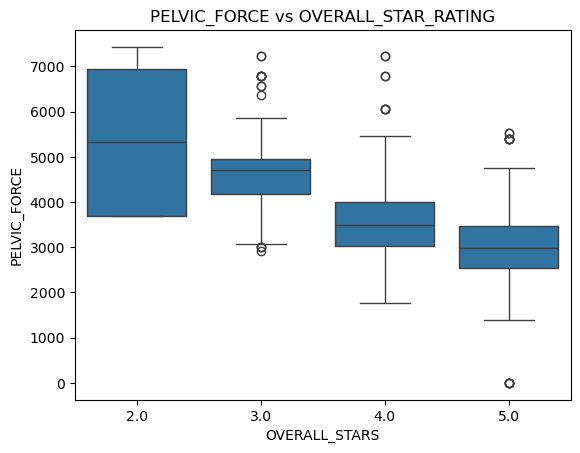

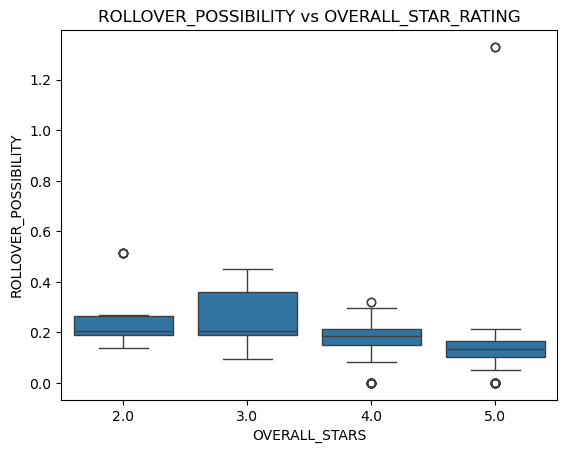

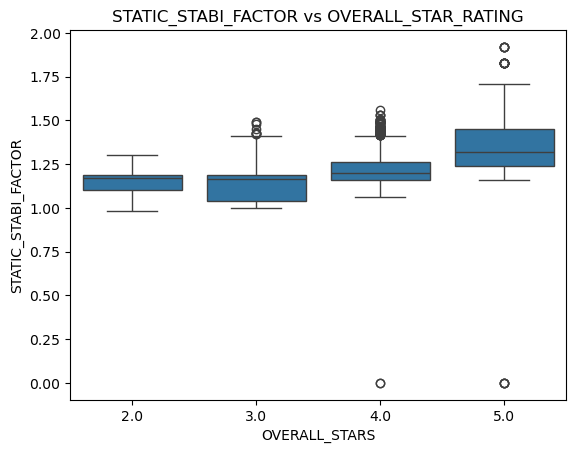

In [17]:
# Boxplot example: numerical vs. target (outliers can be detected here)
for col in numerical_cols:
    sns.boxplot(x='OVERALL_STARS', y=col, data=df_clean)
    plt.title(f'{col} vs OVERALL_STAR_RATING')
    plt.show()


In [18]:
df_clean.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 5128 entries, 2 to 11752
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   MAKE                          5128 non-null   object 
 1   MODEL                         5128 non-null   object 
 2   MODEL_YR                      5128 non-null   int64  
 3   BODY_STYLE                    5128 non-null   object 
 4   VEHICLE_TYPE                  5128 non-null   object 
 5   DRIVE_TRAIN                   5128 non-null   object 
 6   VEHICLE_CLASS                 2928 non-null   object 
 7   BODY_FRAME                    5127 non-null   object 
 8   NUM_OF_SEATING                5127 non-null   object 
 9   SEAT_LOC                      5127 non-null   object 
 10  MIN_GROSS_WEIGHT              4722 non-null   float64
 11  MAX_GROSS_WEIGHT              4726 non-null   float64
 12  UPPER_BELT_ANCHORAGE          4751 non-null   object 
 13  UPPER_B

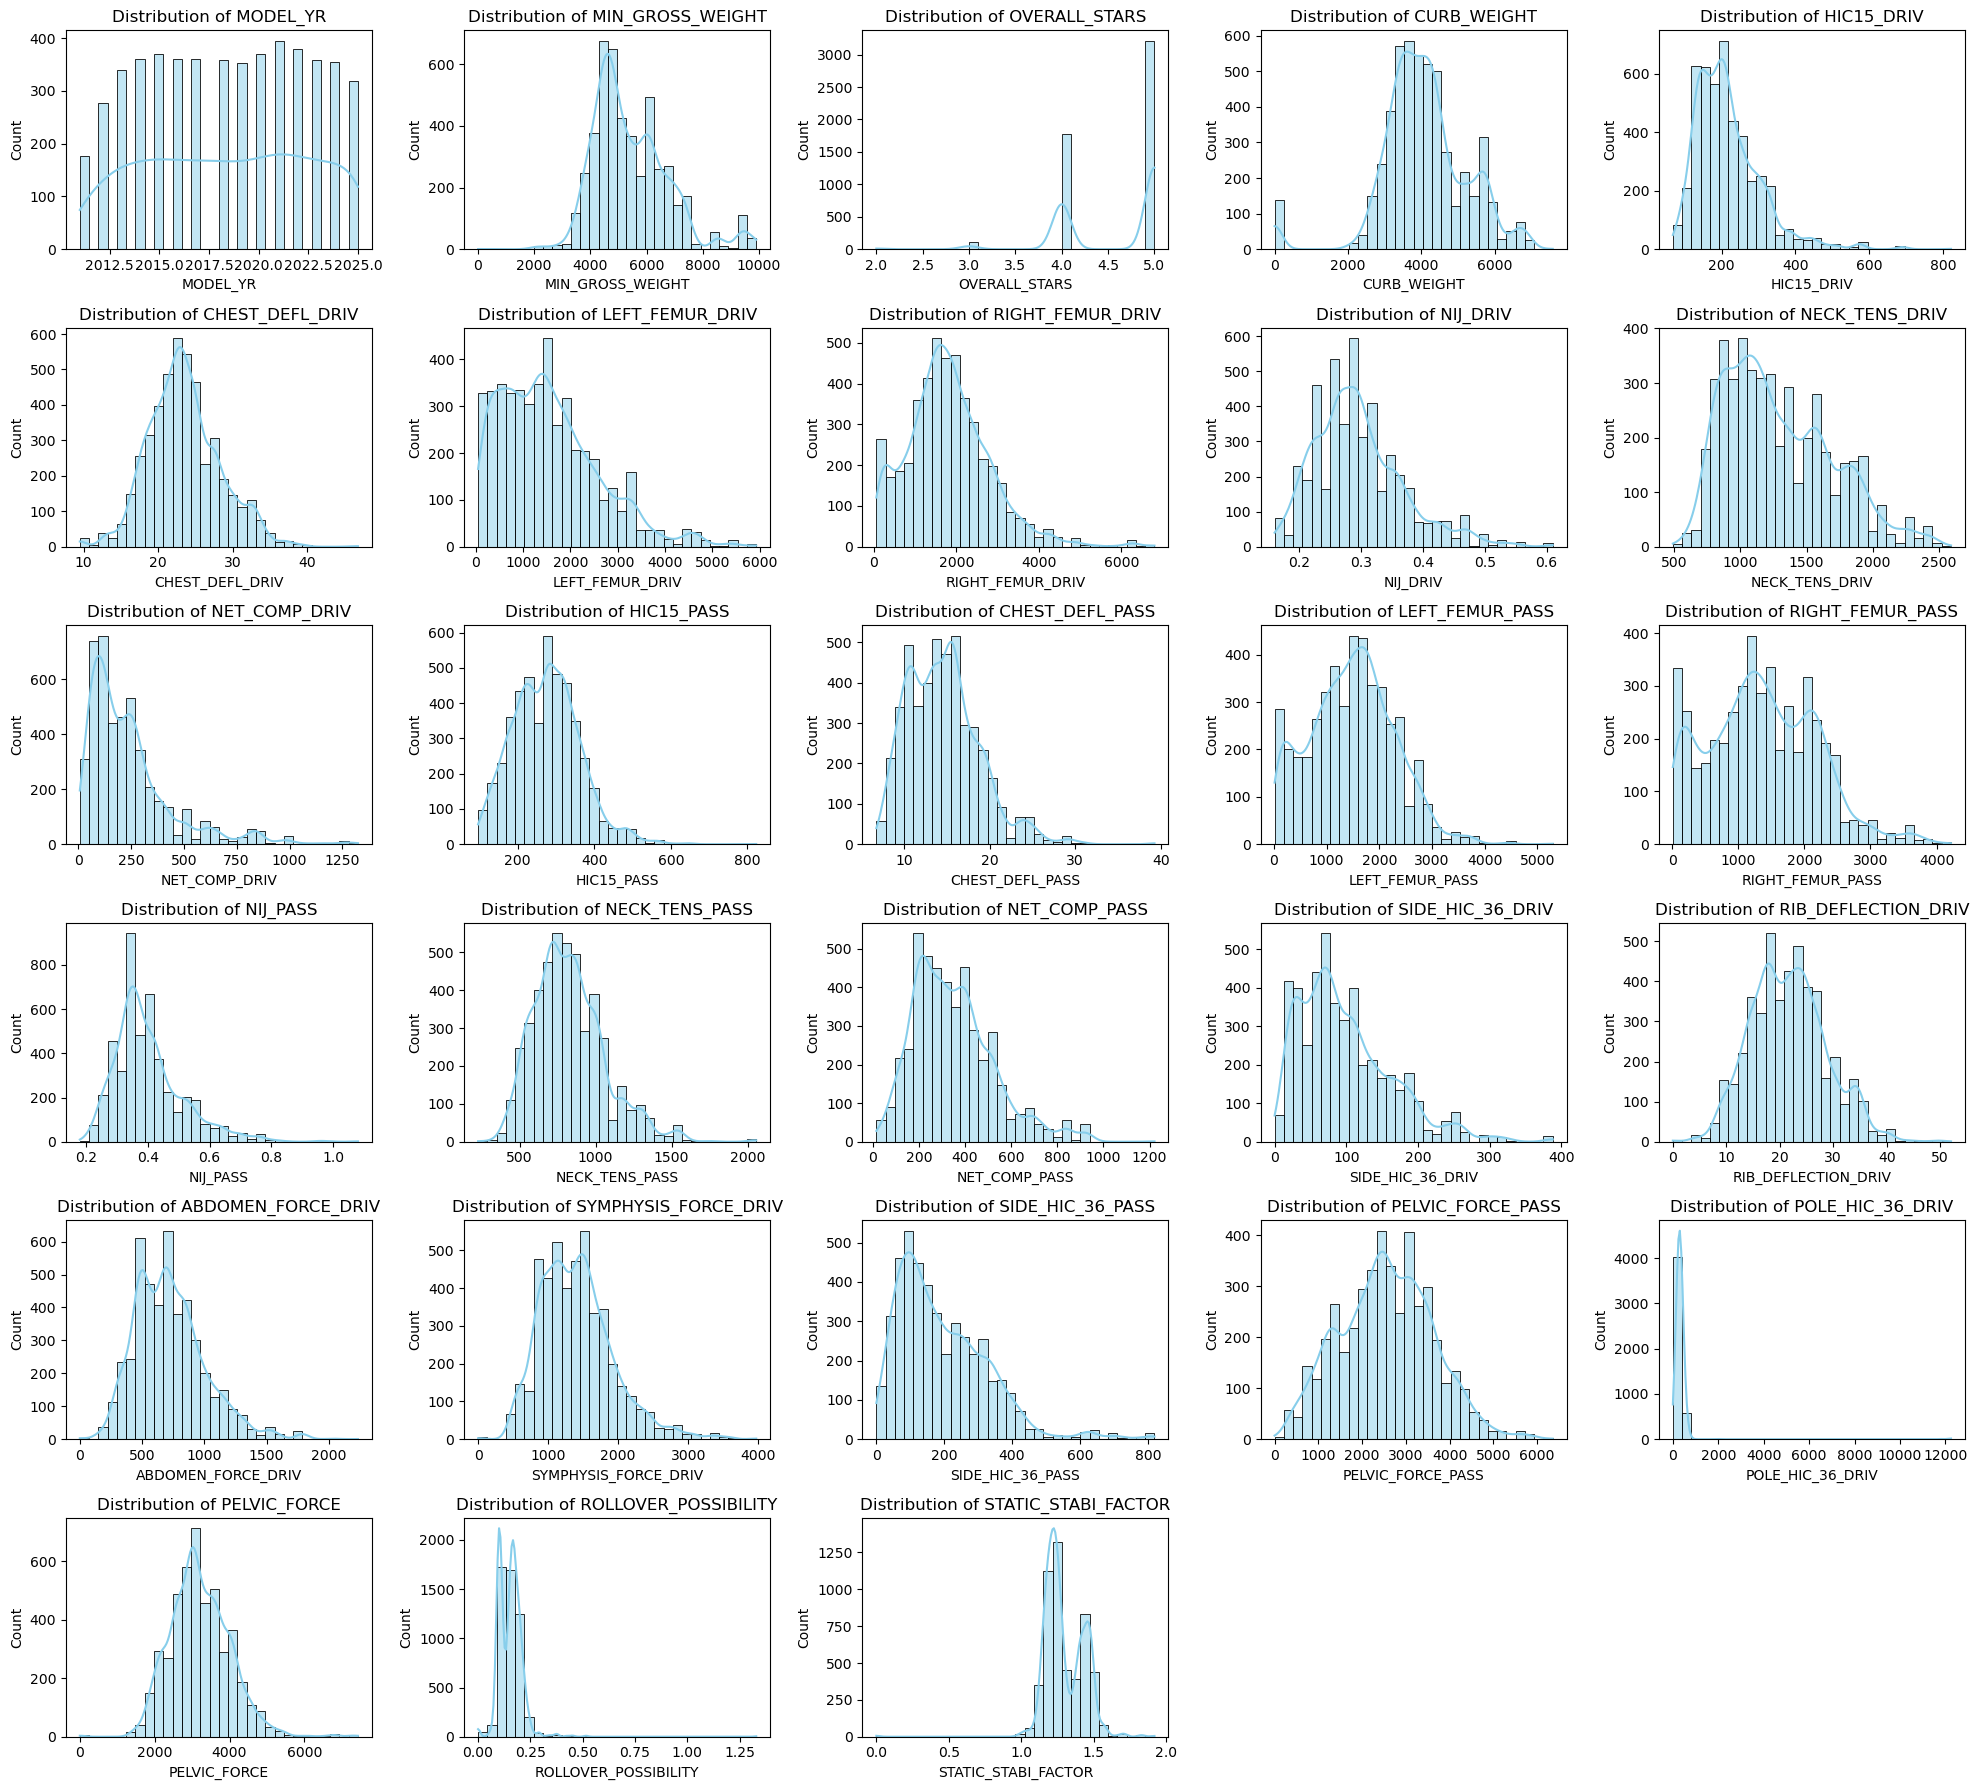

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Number of plots
num_cols = len(numerical_cols)
cols_per_row = 5
num_rows = math.ceil(num_cols / cols_per_row)

plt.figure(figsize=(20, num_rows * 3))  # Adjust width for 5 plots per row

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(num_rows, cols_per_row, i)
    sns.histplot(df_clean[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


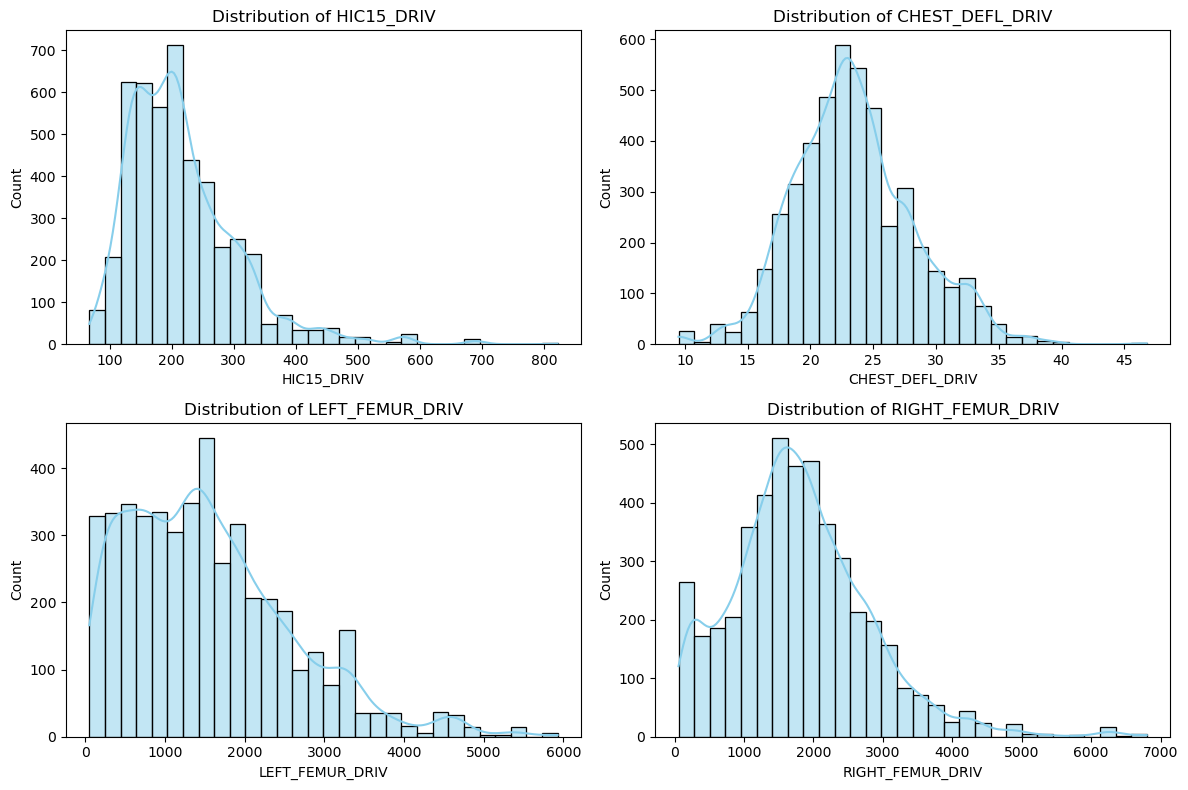

In [20]:
#Distribution of Crash Test Metrics

crash_test_metrics = ['HIC15_DRIV', 'CHEST_DEFL_DRIV', 'LEFT_FEMUR_DRIV', 'RIGHT_FEMUR_DRIV']
plt.figure(figsize=(12, 8))
for i, col in enumerate(crash_test_metrics, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

HIC15_DRIV (Head Injury Criterion): Most vehicles score below 500 (lower is better).
Chest Deflection: Majority fall between 20-30 mm (lower = safer).
Femur Loads: Most vehicles keep forces below 2000 lbs (lower = safer).

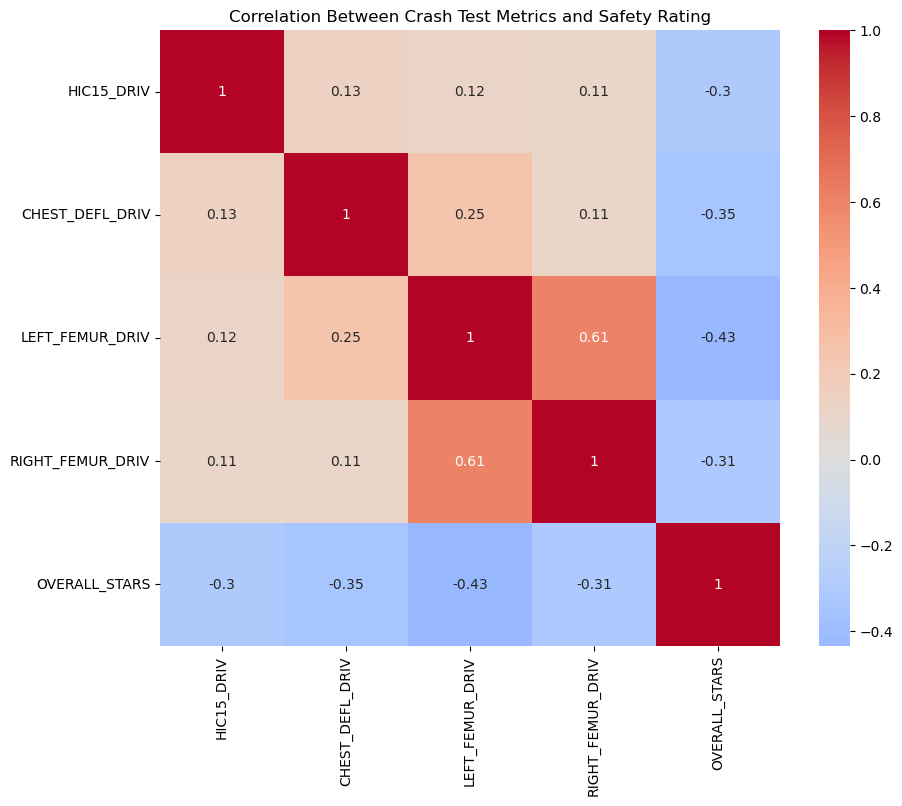

In [22]:
# Correlation Heatmap (Key Crash Test Metrics)

corr_matrix = df_clean[['HIC15_DRIV', 'CHEST_DEFL_DRIV', 'LEFT_FEMUR_DRIV', 'RIGHT_FEMUR_DRIV', 'OVERALL_STARS']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Crash Test Metrics and Safety Rating')
plt.show()

Negative correlation between crash test metrics (HIC15_DRIV, CHEST_DEFL_DRIV) and OVERALL_STARS (higher injury metrics → lower safety rating).
Femur loads show weaker correlation, suggesting other factors (e.g., airbags) may mitigate injury risk.

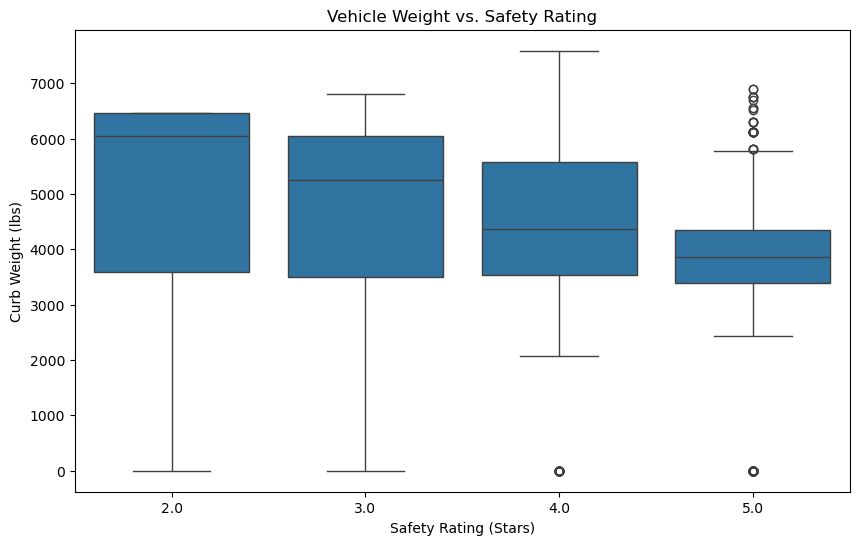

In [24]:
# Vehicle Weight vs. Safety Rating

plt.figure(figsize=(10, 6))
sns.boxplot(x='OVERALL_STARS', y='CURB_WEIGHT', data=df_clean)
plt.title('Vehicle Weight vs. Safety Rating')
plt.xlabel('Safety Rating (Stars)')
plt.ylabel('Curb Weight (lbs)')
plt.show()

Heavier vehicles (SUVs, trucks) tend to have higher safety ratings (4-5 stars).
Lighter vehicles (sedans, compacts) show more variability in ratings.

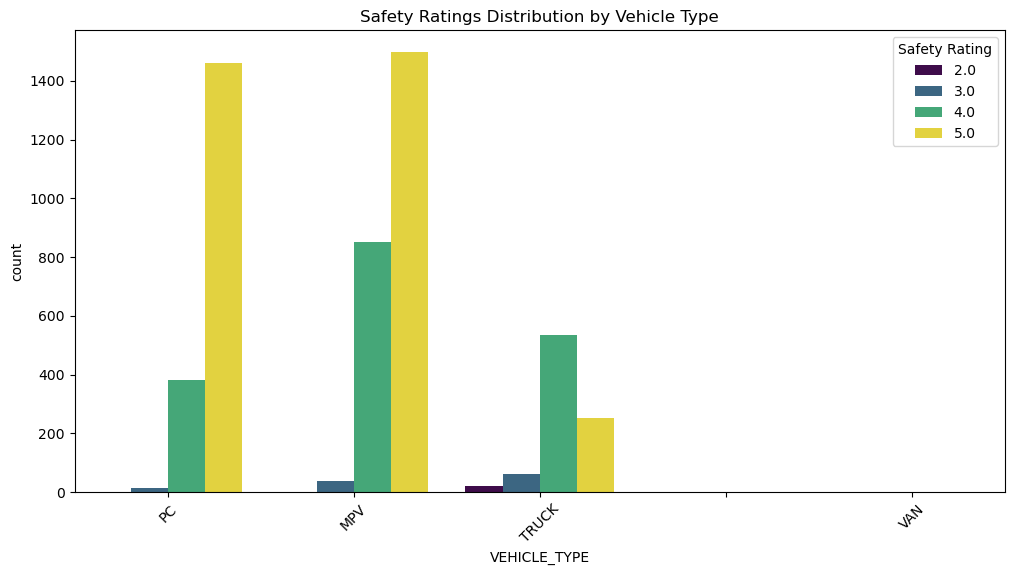

In [26]:
#Safety Ratings by Vehicle Type

plt.figure(figsize=(12, 6))
sns.countplot(x='VEHICLE_TYPE', hue='OVERALL_STARS', data=df_clean, palette='viridis')
plt.title('Safety Ratings Distribution by Vehicle Type')
plt.xticks(rotation=45)
plt.legend(title='Safety Rating')
plt.show()

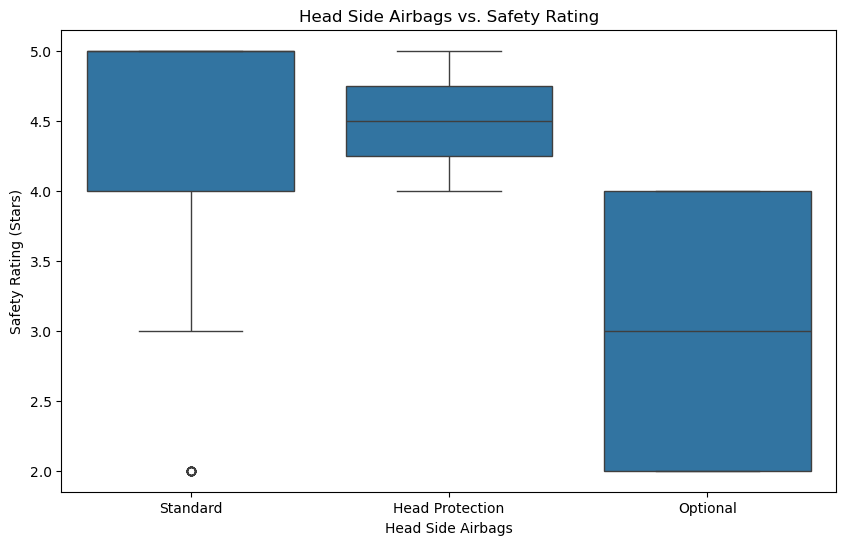

In [27]:
#Impact of Airbags on Safety Ratings
plt.figure(figsize=(10, 6))
sns.boxplot(x='HEAD_SAB', y='OVERALL_STARS', data=df_clean)
plt.title('Head Side Airbags vs. Safety Rating')
plt.xlabel('Head Side Airbags')
plt.ylabel('Safety Rating (Stars)')
plt.show()


Vehicles with Standard air bags have variation but mostly falls under 4-5 stars
Head protection airbags mostly are more safer.

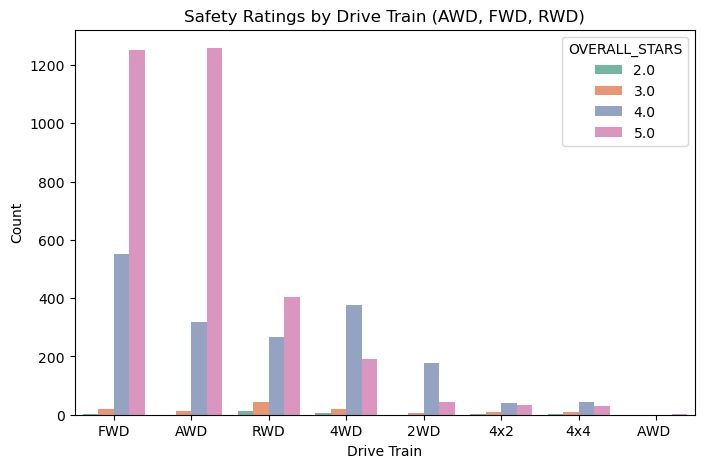

In [29]:
#Safety Ratings by Drive Train

plt.figure(figsize=(8, 5))
sns.countplot(x='DRIVE_TRAIN', hue='OVERALL_STARS', data=df_clean, palette='Set2')
plt.title('Safety Ratings by Drive Train (AWD, FWD, RWD)')
plt.xlabel('Drive Train')
plt.ylabel('Count')
plt.show()

AWD (All-Wheel Drive) and FWD (Front-Wheel Drive) vehicles have the highest proportion of 5-star ratings.

RWD (Rear-Wheel Drive) show more variability.

Other drive trains have less 5-star ratings

Test Train Split

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


In [32]:
# spliting the dataset 

# Select numerical features only for a simple model
numerical_cols = [col for col in numerical_cols if col != 'OVERALL_STARS']

X = df_clean[numerical_cols]
y = df_clean['OVERALL_STARS']

# Handle missing values as median as the data is skewed
X = X.fillna(X.median())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Modelling

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import time

In [35]:


# Set up result storage
results = {}

# -----------------------------
# Evaluation Metric Justification
# -----------------------------
# We are using F1-macro as the scoring metric for model selection.
# This is appropriate for multiclass classification problems with potential class imbalance,
# as it treats all classes equally regardless of their frequency.
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

# -----------------------------
# Logistic Regression
# -----------------------------
print("Training Logistic Regression...")
start = time.time()
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)
best_linear_lg = grid.best_estimator_
runtime = time.time() - start
test_acc = accuracy_score(y_test, best_linear_lg.predict(X_test))
results['Logistic Regression'] = (test_acc, runtime)
print(f"Logistic Regression | Test Acc: {test_acc:.4f} | Time: {runtime:.2f}s")

# -----------------------------
# Linear SVM
# -----------------------------
print("\nTraining Linear SVM...")
start = time.time()
param_grid = {'C': [0.01, 0.1, 1, 5, 10]}
grid = GridSearchCV(SVC(kernel='linear'), param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)
best_linear_svm = grid.best_estimator_
runtime = time.time() - start
test_acc = accuracy_score(y_test, best_linear_svm.predict(X_test))
results['Linear SVM'] = (test_acc, runtime)
print(f"Linear SVM | Test Acc: {test_acc:.4f} | Time: {runtime:.2f}s")

# -----------------------------
# RBF SVM
# -----------------------------
print("\nTraining RBF SVM...")
start = time.time()
param_grid = {'C': [1, 10], 'gamma': ['scale', 0.01, 0.001]}
grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)
best_rbf_svm = grid.best_estimator_
runtime = time.time() - start
test_acc = accuracy_score(y_test, best_rbf_svm.predict(X_test))
results['RBF SVM'] = (test_acc, runtime)
print(f"RBF SVM | Test Acc: {test_acc:.4f} | Time: {runtime:.2f}s")

# -----------------------------
# Random Forest
# -----------------------------
print("\nTraining Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True, n_jobs=-1)
rf.fit(X_train, y_train)
runtime = time.time() - start
test_acc = accuracy_score(y_test, rf.predict(X_test))
oob_error = 1 - rf.oob_score_
results['Random Forest'] = (test_acc, runtime)
print(f"Random Forest | Test Acc: {test_acc:.4f} | Time: {runtime:.2f}s | OOB Error: {oob_error:.4f}")




# -----------------------------
# Decision Tree
# -----------------------------
print("\nTraining Decision Tree...")
start = time.time()
param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)
best_dt = grid.best_estimator_
runtime = time.time() - start
test_acc = accuracy_score(y_test, best_dt.predict(X_test))
results['Decision Tree'] = (test_acc, runtime)
print(f"Decision Tree | Test Acc: {test_acc:.4f} | Time: {runtime:.2f}s")


from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# K-Nearest Neighbors (KNN)
# -----------------------------
print("\nTraining K-Nearest Neighbors...")
start = time.time()
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid.fit(X_train, y_train)
best_knn = grid.best_estimator_
runtime = time.time() - start
test_acc = accuracy_score(y_test, best_knn.predict(X_test))
results['KNN'] = (test_acc, runtime)
print(f"KNN | Test Acc: {test_acc:.4f} | Time: {runtime:.2f}s")




Training Logistic Regression...
Logistic Regression | Test Acc: 0.9113 | Time: 3.12s

Training Linear SVM...
Linear SVM | Test Acc: 0.9191 | Time: 13.27s

Training RBF SVM...
RBF SVM | Test Acc: 0.9600 | Time: 6.93s

Training Random Forest...
Random Forest | Test Acc: 0.9864 | Time: 0.18s | OOB Error: 0.0141

Training Decision Tree...
Decision Tree | Test Acc: 0.9815 | Time: 6.13s

Training K-Nearest Neighbors...
KNN | Test Acc: 0.9825 | Time: 3.16s


In [96]:
# precision recall plot

Random Forest | Test Acc: 0.9873 | Time: 1.75s


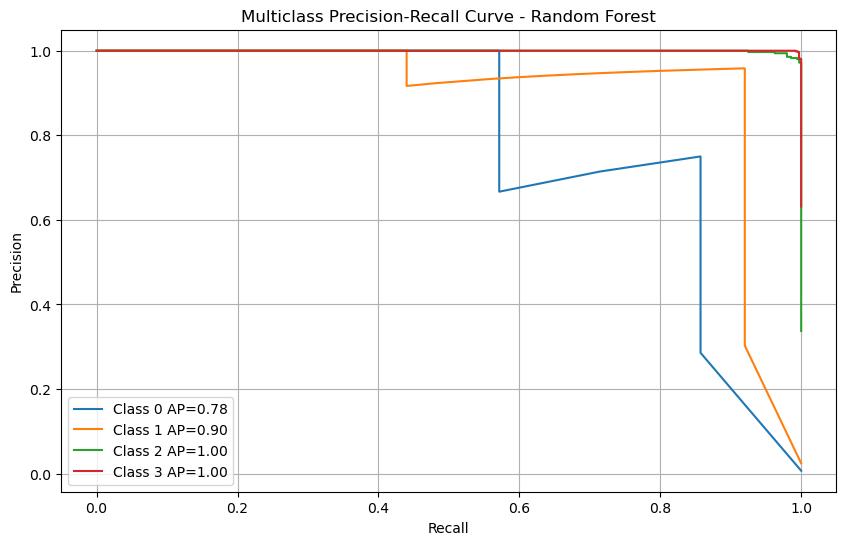

In [40]:


# One-vs-rest for Random Forest
ovr_rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
start = time.time()
ovr_rf.fit(X_train, y_train)
y_score = ovr_rf.predict_proba(X_test)  # Use predict_proba for multiclass probabilities
runtime = time.time() - start
test_acc = accuracy_score(y_test, ovr_rf.predict(X_test))  # Calculate accuracy on test set
print(f"Random Forest | Test Acc: {test_acc:.4f} | Time: {runtime:.2f}s")

# Binarize labels for Precision-Recall
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Plot Precision-Recall curves for each class
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_score[:, i])  # Calculate average precision (AP)
    plt.plot(recall, precision, label=f"Class {i} AP={avg_precision:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision-Recall Curve - Random Forest")
plt.legend(loc="lower left")
plt.grid()
plt.show()


Hyperparameter tuning

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest | Test Acc: 0.9864 | Time: 29.63s
Best hyperparameters found: {'estimator__n_estimators': 150, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 1, 'estimator__max_features': 'log2', 'estimator__max_depth': None, 'estimator__bootstrap': True}


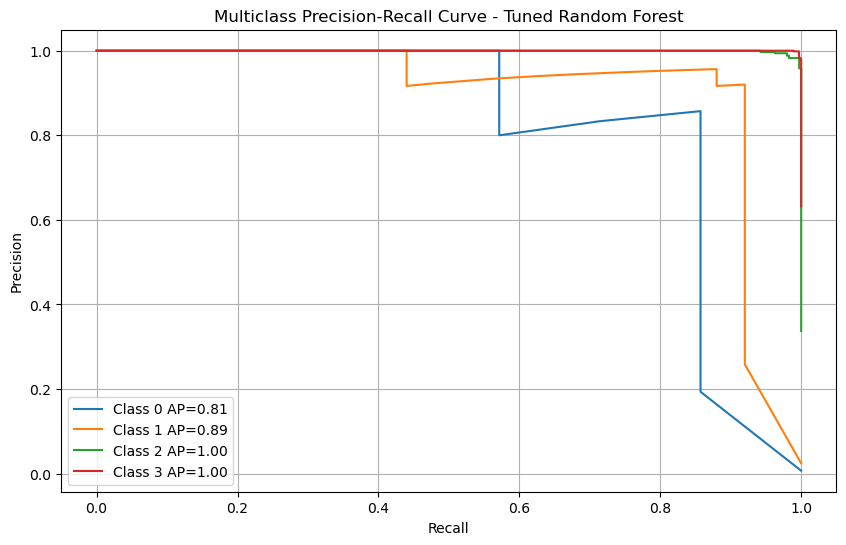

In [92]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import time
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Define the hyperparameter grid for Random Forest
param_dist = {
    'estimator__n_estimators': np.arange(50, 201, 50),  # Number of trees
    'estimator__max_depth': [None, 10, 20, 30, 40, 50],  # Max depth of trees
    'estimator__min_samples_split': [2, 5, 10, 15],  # Min samples required to split
    'estimator__min_samples_leaf': [1, 2, 4, 6],  # Min samples required at leaf node
    'estimator__max_features': ['auto', 'sqrt', 'log2'],  # Max features to consider
    'estimator__bootstrap': [True, False]  # Whether to use bootstrap sampling
}

# One-vs-rest for Random Forest with RandomizedSearchCV
ovr_rf = OneVsRestClassifier(RandomForestClassifier(random_state=42))

# Use RandomizedSearchCV for faster hyperparameter tuning
start = time.time()
random_search = RandomizedSearchCV(
    ovr_rf, param_dist, n_iter=20, cv=5, verbose=2, n_jobs=-1, scoring='accuracy', random_state=42
)
random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

# Calculate the runtime and test accuracy for the best model
runtime = time.time() - start
test_acc = accuracy_score(y_test, best_rf.predict(X_test))
print(f"Best Random Forest | Test Acc: {test_acc:.4f} | Time: {runtime:.2f}s")

# Get the best parameters from RandomizedSearchCV
print("Best hyperparameters found:", random_search.best_params_)

# Get predictions and probabilities for Precision-Recall Curve
y_score = best_rf.predict_proba(X_test)

# Binarize labels for Precision-Recall
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Plot Precision-Recall curves for each class
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_score[:, i])  # Calculate average precision (AP)
    plt.plot(recall, precision, label=f"Class {i} AP={avg_precision:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision-Recall Curve - Tuned Random Forest")
plt.legend(loc="lower left")
plt.grid()
plt.show()


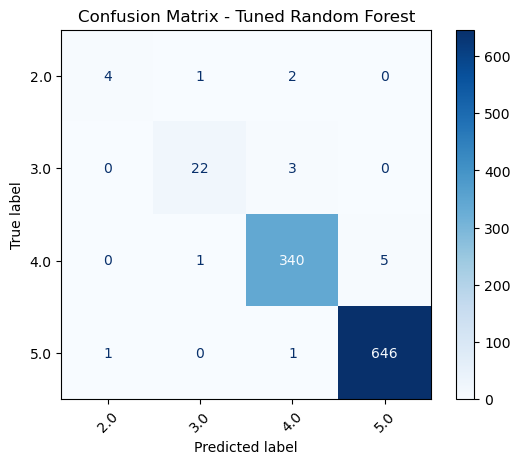

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on the test data
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.grid(False)
plt.show()


In [43]:
from sklearn.metrics import classification_report, confusion_matrix

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


XGBoost Classification Report:
              precision    recall  f1-score   support

           2       0.80      0.57      0.67         7
           3       0.92      0.88      0.90        25
           4       0.98      0.98      0.98       346
           5       0.99      1.00      0.99       648

    accuracy                           0.99      1026
   macro avg       0.92      0.86      0.89      1026
weighted avg       0.99      0.99      0.99      1026

Confusion Matrix:
[[  4   1   2   0]
 [  0  22   3   0]
 [  0   1 340   5]
 [  1   0   1 646]]


Top 10 Important Features:
                 Feature  Importance
25  ROLLOVER_POSSIBILITY    0.122735
26   STATIC_STABI_FACTOR    0.121851
2            CURB_WEIGHT    0.090164
1       MIN_GROSS_WEIGHT    0.082771
15        NECK_TENS_PASS    0.072944
14              NIJ_PASS    0.058138
0               MODEL_YR    0.055913
19    ABDOMEN_FORCE_DRIV    0.046962
24          PELVIC_FORCE    0.041011
18   RIB_DEFLECTION_DRIV    0.037137


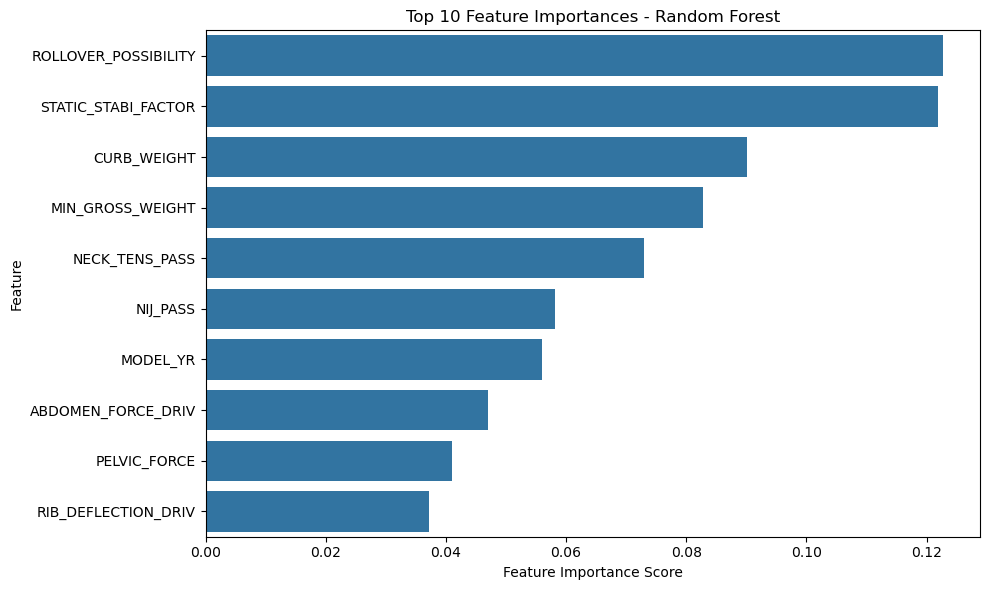

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the inner Random Forest model from OneVsRestClassifier
rf_inner = best_rf.estimators_[0]  # You can inspect more trees if needed

# Get feature importances
importances = rf_inner.feature_importances_
feature_names = X.columns  # Make sure X is a DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top 10 features
print("Top 10 Important Features:")
print(feature_importance_df.head(10))

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [45]:
df_temp = df_clean.sort_values(by='ROLLOVER_POSSIBILITY', ascending=False)
unique_make_model = df_temp[['MAKE', 'MODEL']].drop_duplicates()
print(unique_make_model.head(5))

            MAKE                              MODEL
2397  VOLKSWAGEN                          JETTA GLI
1846        FORD   TRANSIT HIGH ROOF (8,10,12) PASS
217         FORD          TRANSIT HIGH ROOF 12 PASS
1848        FORD          TRANSIT HIGH ROOF 15 PASS
6076        FORD  TRANSIT MEDIUM ROOF(8,10,12) PASS
